<a href="https://colab.research.google.com/github/hetaf234/GP_Layers/blob/main/image_recognition_model_using_food101_(EfficientNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connecting to google drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

FOOD101_PATH = '/content/drive/MyDrive/Graduation_Project/food-101/food-101/images'
meta_path = '/content/drive/MyDrive/Graduation_Project/food-101/food-101/meta'

print("Images path exists:", os.path.exists(FOOD101_PATH))
print("Meta path exists:", os.path.exists(meta_path))

Images path exists: True
Meta path exists: True


In [12]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [13]:
LOCAL_FOOD101_PATH = '/content/food-101-local'
print("Local copy exists:", os.path.exists(LOCAL_FOOD101_PATH))

Local copy exists: True


if copy not exists use this code below

In [ ]:
import shutil, time

print("Copying images to local disk...")
start = time.time()
shutil.copytree(FOOD101_PATH, LOCAL_FOOD101_PATH)
print(f"Copy completed in {(time.time()-start)/60:.1f} minutes")

خلاص بس هالجزء فوق اللي ينسخ

In [18]:
with open(os.path.join(meta_path, 'classes.txt')) as f:
    classes_list = f.read().splitlines()

print(f"Number of classes: {len(classes_list)}")

Number of classes: 101


In [14]:
def load_split(split_file, images_root):
    with open(split_file) as f:
        entries = f.read().splitlines()

    image_paths = []
    labels = []
    for entry in entries:
        class_name, image_id = entry.split('/')
        full_path = os.path.join(images_root, class_name, image_id + '.jpg')
        image_paths.append(full_path)
        labels.append(class_name)

    return image_paths, labels

train_paths, train_labels = load_split(os.path.join(meta_path, 'train.txt'), LOCAL_FOOD101_PATH)
test_paths, test_labels = load_split(os.path.join(meta_path, 'test.txt'), LOCAL_FOOD101_PATH)

print(f"Train samples: {len(train_paths)}")
print(f"Test samples: {len(test_paths)}")

Train samples: 75750
Test samples: 25250


In [15]:
from collections import Counter

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("Train - min/max per class:", min(train_counts.values()), max(train_counts.values()))
print("Test - min/max per class:", min(test_counts.values()), max(test_counts.values()))

Train - min/max per class: 750 750
Test - min/max per class: 250 250


In [16]:
from sklearn.model_selection import train_test_split

train_paths_final, val_paths, train_labels_final, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=42
)

print(f"Final train samples: {len(train_paths_final)}")
print(f"Validation samples: {len(val_paths)}")

Final train samples: 64387
Validation samples: 11363


In [19]:
class_to_idx = {class_name: idx for idx, class_name in enumerate(sorted(classes_list))}
print(f"Number of classes: {len(class_to_idx)}")

Number of classes: 101


In [20]:
from torch.utils.data import Dataset
from PIL import Image

class Food101Dataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label_name = self.labels[index]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label_idx = self.class_to_idx[label_name]
        return image, label_idx

print("Food101Dataset class defined")

Food101Dataset class defined


In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined")

Transforms defined


In [22]:
train_dataset = Food101Dataset(train_paths_final, train_labels_final, class_to_idx, transform=train_transform)
val_dataset = Food101Dataset(val_paths, val_labels, class_to_idx, transform=test_transform)
test_dataset = Food101Dataset(test_paths, test_labels, class_to_idx, transform=test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 64387 | Val: 11363 | Test: 25250


In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("DataLoaders created")

DataLoaders created


In [24]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

print("Training functions defined")

Training functions defined


In [25]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

model_eff = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model_eff.parameters():
    param.requires_grad = False

model_eff.classifier[1] = nn.Linear(model_eff.classifier[1].in_features, 101)
model_eff = model_eff.to(device)

print("EfficientNet-B0 ready with 101 output classes")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


EfficientNet-B0 ready with 101 output classes


In [26]:
import torch.optim as optim

criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = optim.Adam(model_eff.classifier[1].parameters(), lr=0.001, weight_decay=1e-4)
scheduler_eff = optim.lr_scheduler.StepLR(optimizer_eff, step_size=5, gamma=0.1)

print("Feature extraction tools ready")

Feature extraction tools ready


In [27]:
PROJECT_PATH_EFF = '/content/drive/MyDrive/Graduation_Project/food101_results_efficientnet'
os.makedirs(PROJECT_PATH_EFF, exist_ok=True)

NUM_EPOCHS_EFF = 20
best_acc_eff = 0.0

train_losses_eff, val_losses_eff = [], []
train_accs_eff, val_accs_eff = [], []

for epoch in range(NUM_EPOCHS_EFF):
    print(f"\n--- Feature Extraction Epoch {epoch+1}/{NUM_EPOCHS_EFF} ---")

    train_loss, train_acc = train_one_epoch(model_eff, train_loader, criterion_eff, optimizer_eff, device)
    val_loss, val_acc = validate(model_eff, val_loader, criterion_eff, device)
    scheduler_eff.step()

    train_losses_eff.append(train_loss)
    val_losses_eff.append(val_loss)
    train_accs_eff.append(train_acc)
    val_accs_eff.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, 'last_checkpoint.pth'))

    if val_acc > best_acc_eff:
        best_acc_eff = val_acc
        torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, 'best_model.pth'))
        print("✅ Best EfficientNet model saved")

print(f"\nFeature Extraction complete! Best: {best_acc_eff:.2f}%")


--- Feature Extraction Epoch 1/20 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.13it/s]


Train Loss: 2.7425 | Train Acc: 37.53%
Val Loss: 2.1211 | Val Acc: 49.28%
✅ Best EfficientNet model saved

--- Feature Extraction Epoch 2/20 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.90it/s]


Train Loss: 2.2441 | Train Acc: 45.80%
Val Loss: 2.0280 | Val Acc: 50.66%
✅ Best EfficientNet model saved

--- Feature Extraction Epoch 3/20 ---


...

Train Loss: 1.9324 | Train Acc: 51.85%
Val Loss: 1.8632 | Val Acc: 54.37%

--- Feature Extraction Epoch 19/20 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.06it/s]


Train Loss: 1.9206 | Train Acc: 52.39%
Val Loss: 1.8351 | Val Acc: 54.90%

--- Feature Extraction Epoch 20/20 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.63it/s]


Train Loss: 1.9297 | Train Acc: 51.88%
Val Loss: 1.8355 | Val Acc: 54.92%
✅ Best EfficientNet model saved

Feature Extraction complete! Best: 54.92%


In [28]:
model_eff.load_state_dict(torch.load(os.path.join(PROJECT_PATH_EFF, 'best_model.pth')))
print(f"Loaded best model (54.92%)")

Loaded best model (54.92%)


In [29]:
for param in model_eff.features[-5:].parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model_eff.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 4,071,199


In [30]:
import torch.optim as optim

optimizer_eff_ft = optim.Adam([
    {'params': model_eff.classifier[1].parameters(), 'lr': 1e-4},
    {'params': model_eff.features[-5:].parameters(), 'lr': 1e-5}
])

scheduler_eff_ft = optim.lr_scheduler.StepLR(optimizer_eff_ft, step_size=3, gamma=0.1)

print("Fine-tuning tools ready")

Fine-tuning tools ready


In [31]:
NUM_EPOCHS_EFF_FT = 15
best_acc_eff_ft = 54.92

train_losses_eff_ft, val_losses_eff_ft = [], []
train_accs_eff_ft, val_accs_eff_ft = [], []

for epoch in range(NUM_EPOCHS_EFF_FT):
    print(f"\n--- Fine-tune Epoch {epoch+1}/{NUM_EPOCHS_EFF_FT} ---")

    train_loss, train_acc = train_one_epoch(model_eff, train_loader, criterion_eff, optimizer_eff_ft, device)
    val_loss, val_acc = validate(model_eff, val_loader, criterion_eff, device)
    scheduler_eff_ft.step()

    train_losses_eff_ft.append(train_loss)
    val_losses_eff_ft.append(val_loss)
    train_accs_eff_ft.append(train_acc)
    val_accs_eff_ft.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, 'last_checkpoint_finetuned.pth'))

    if val_acc > best_acc_eff_ft:
        best_acc_eff_ft = val_acc
        torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, 'best_model_finetuned.pth'))
        print("✅ Best fine-tuned model saved")

print(f"\nFine-tuning complete! Best: {best_acc_eff_ft:.2f}%")
print(f"Improvement: {best_acc_eff_ft - 54.92:.2f}%")


--- Fine-tune Epoch 1/15 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.08it/s]


Train Loss: 1.6928 | Train Acc: 57.31%
Val Loss: 1.4961 | Val Acc: 62.23%
✅ Best fine-tuned model saved

--- Fine-tune Epoch 2/15 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.41it/s]


Train Loss: 1.4568 | Train Acc: 62.45%
Val Loss: 1.3351 | Val Acc: 66.00%
✅ Best fine-tuned model saved

--- Fine-tune Epoch 3/15 ---


...

Train Loss: 1.2319 | Train Acc: 67.60%
Val Loss: 1.2350 | Val Acc: 67.75%

--- Fine-tune Epoch 14/15 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.42it/s]


Train Loss: 1.2293 | Train Acc: 67.70%
Val Loss: 1.2476 | Val Acc: 67.50%

--- Fine-tune Epoch 15/15 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.45it/s]

Train Loss: 1.2354 | Train Acc: 67.45%
Val Loss: 1.2366 | Val Acc: 68.16%

Fine-tuning complete! Best: 68.49%
Improvement: 13.57%


In [32]:
model_eff.load_state_dict(torch.load(os.path.join(PROJECT_PATH_EFF, 'best_model_finetuned.pth')))
print("Loaded best model (68.49%)")

Loaded best model (68.49%)


نفك تجميد المودل كامل مو جزئي

In [33]:
for param in model_eff.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model_eff.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_eff.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} (100%)")

Trainable parameters: 4,136,929 / 4,136,929 (100%)


In [34]:
optimizer_eff_full = optim.Adam(model_eff.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_eff_full = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff_full, T_max=25)
print("Full fine-tuning tools ready")

Full fine-tuning tools ready


In [35]:
NUM_EPOCHS_FULL = 25
best_acc_full = 68.49
MODEL_NAME = "EfficientNet-B0"

for epoch in range(NUM_EPOCHS_FULL):
    print(f"\n--- Full Fine-tune Epoch {epoch+1}/{NUM_EPOCHS_FULL} ---")

    train_loss, train_acc = train_one_epoch(model_eff, train_loader, criterion_eff, optimizer_eff_full, device)
    val_loss, val_acc = validate(model_eff, val_loader, criterion_eff, device)
    scheduler_eff_full.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    last_filename = f"{MODEL_NAME}_last_checkpoint.pth"
    torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, last_filename))

    if val_acc > best_acc_full:
        best_acc_full = val_acc
        best_filename = f"{MODEL_NAME}_best_fullfinetune_{val_acc:.2f}pct.pth"
        torch.save(model_eff.state_dict(), os.path.join(PROJECT_PATH_EFF, best_filename))
        print(f"✅ Saved: {best_filename}")

print(f"\nFull fine-tuning complete! Best: {best_acc_full:.2f}%")


--- Full Fine-tune Epoch 1/25 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.92it/s]


Train Loss: 1.2110 | Train Acc: 68.18%
Val Loss: 1.1763 | Val Acc: 69.53%
✅ Saved: EfficientNet-B0_best_fullfinetune_69.53pct.pth

--- Full Fine-tune Epoch 2/25 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.74it/s]


Train Loss: 1.1466 | Train Acc: 69.58%
Val Loss: 1.1280 | Val Acc: 70.56%
✅ Saved: EfficientNet-B0_best_fullfinetune_70.56pct.pth

--- Full Fine-tune Epoch 3/25 ---


...

Train Loss: 0.7066 | Train Acc: 80.69%
Val Loss: 0.9159 | Val Acc: 75.65%

--- Full Fine-tune Epoch 24/25 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 23.45it/s]


Train Loss: 0.7066 | Train Acc: 80.61%
Val Loss: 0.9172 | Val Acc: 75.49%

--- Full Fine-tune Epoch 25/25 ---


Validating: 100%|██████████| 356/356 [00:15<00:00, 22.94it/s]

Train Loss: 0.7074 | Train Acc: 80.47%
Val Loss: 0.9241 | Val Acc: 75.43%

Full fine-tuning complete! Best: 75.83%


In [36]:
# Check if these variables still exist from your training sessions
variables_needed = ['train_accs_eff', 'val_accs_eff', 'train_losses_eff', 'val_losses_eff',
                     'train_accs_eff_ft', 'val_accs_eff_ft', 'train_losses_eff_ft', 'val_losses_eff_ft',
                     'train_accs_full', 'val_accs_full', 'train_losses_full', 'val_losses_full']

for var in variables_needed:
    print(f"{var}: {'✅ exists' if var in dir() else '❌ missing'}")

train_accs_eff: ✅ exists
val_accs_eff: ✅ exists
train_losses_eff: ✅ exists
val_losses_eff: ✅ exists
train_accs_eff_ft: ✅ exists
val_accs_eff_ft: ✅ exists
train_losses_eff_ft: ✅ exists
val_losses_eff_ft: ✅ exists
train_accs_full: ❌ missing
val_accs_full: ❌ missing
train_losses_full: ❌ missing
val_losses_full: ❌ missing


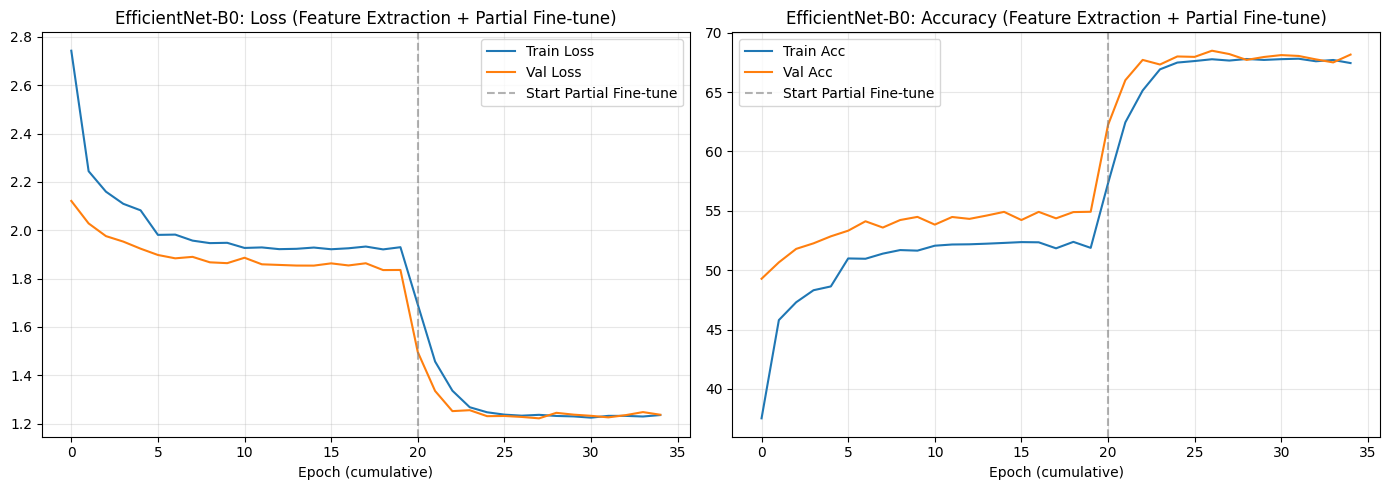

Partial curves saved (Feature Extraction + Partial Fine-tune)


In [37]:
import matplotlib.pyplot as plt

# Combine only the two phases we have detailed data for
all_train_acc = train_accs_eff + train_accs_eff_ft
all_val_acc = val_accs_eff + val_accs_eff_ft
all_train_loss = train_losses_eff + train_losses_eff_ft
all_val_loss = val_losses_eff + val_losses_eff_ft

phase1_end = len(train_accs_eff)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_train_loss, label='Train Loss', color='tab:blue')
axes[0].plot(all_val_loss, label='Val Loss', color='tab:orange')
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.6, label='Start Partial Fine-tune')
axes[0].set_title('EfficientNet-B0: Loss (Feature Extraction + Partial Fine-tune)')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_train_acc, label='Train Acc', color='tab:blue')
axes[1].plot(all_val_acc, label='Val Acc', color='tab:orange')
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.6, label='Start Partial Fine-tune')
axes[1].set_title('EfficientNet-B0: Accuracy (Feature Extraction + Partial Fine-tune)')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH_EFF, 'EfficientNet-B0_partial_curves.png'), dpi=150)
plt.show()

print("Partial curves saved (Feature Extraction + Partial Fine-tune)")

In [1]:
full_finetune_summary = {
    'Epoch 1': 69.53, 'Epoch 5': 72.74, 'Epoch 10': 74.62,
    'Epoch 15': 75.49, 'Epoch 20': 75.49, 'Epoch 22 (best)': 75.83, 'Epoch 25': 75.43
}

print("Full Fine-tuning Progress Summary:")
for epoch, acc in full_finetune_summary.items():
    print(f"  {epoch}: {acc}%")

Full Fine-tuning Progress Summary:
  Epoch 1: 69.53%
  Epoch 5: 72.74%
  Epoch 10: 74.62%
  Epoch 15: 75.49%
  Epoch 20: 75.49%
  Epoch 22 (best): 75.83%
  Epoch 25: 75.43%


Mounted at /content/drive


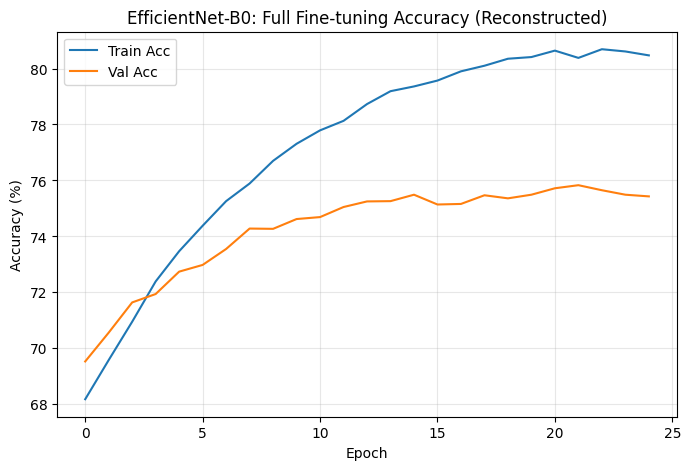

Plot saved successfully


In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import matplotlib.pyplot as plt

PROJECT_PATH_EFF = '/content/drive/MyDrive/Graduation_Project/food101_results_efficientnet'
os.makedirs(PROJECT_PATH_EFF, exist_ok=True)

val_accs_full_manual = [69.53, 70.56, 71.64, 71.94, 72.74, 72.98, 73.55, 74.28, 74.27,
                          74.62, 74.69, 75.05, 75.25, 75.26, 75.49, 75.14, 75.16, 75.47,
                          75.36, 75.49, 75.72, 75.83, 75.65, 75.49, 75.43]

train_accs_full_manual = [68.18, 69.58, 70.95, 72.39, 73.47, 74.38, 75.26, 75.89, 76.70,
                            77.31, 77.79, 78.13, 78.73, 79.19, 79.36, 79.57, 79.90, 80.10,
                            80.35, 80.41, 80.64, 80.38, 80.69, 80.61, 80.47]

plt.figure(figsize=(8, 5))
plt.plot(train_accs_full_manual, label='Train Acc')
plt.plot(val_accs_full_manual, label='Val Acc')
plt.title('EfficientNet-B0: Full Fine-tuning Accuracy (Reconstructed)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(PROJECT_PATH_EFF, 'EfficientNet-B0_fullfinetune_reconstructed.png'), dpi=150)
plt.show()

print("Plot saved successfully")